## Actividad: Redes aleatorias vs redes reales

¿Se puede usar el modelo para intentar describir la estructura y comportamiento de las redes reales? 

Van a realizar la siguiente actividad para la mini-red y una red real.

1. Cargar los datos y crear la red:

In [42]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import plotly.graph_objects as go
import plotly.io as pio
import ipywidgets as widgets
from IPython.display import display
import matplotlib
from matplotlib import colors as mcolors
import seaborn as sns
sns.set_style('whitegrid')

pio.renderers.default = "vscode"
plt.set_cmap("rainbow")

<Figure size 640x480 with 0 Axes>

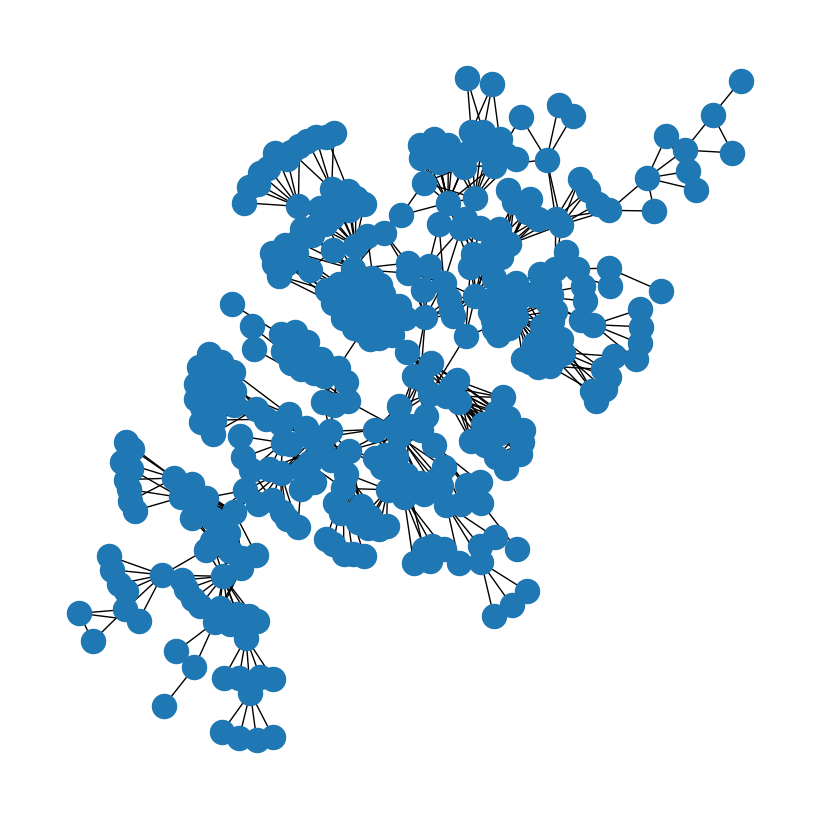

In [8]:
datos = pd.read_csv('data/ca-netscience.mtx', skiprows=2, header=None, sep=' ')
aristas = datos[[0, 1]].values

G = nx.Graph()
G.add_edges_from(aristas)

plt.figure(figsize=[8, 8])
layout = nx.kamada_kawai_layout(G)
nx.draw(G, layout)

2. Una vez que se creó la red, determina $n$ la cantidad de nodos, $m$ el número de aristas, $\langle k\rangle$ el grado promedio y $C_{WS}$ el coeficiente de agrupamiento promedio.

In [10]:
n = len(G)
m = len(G.edges)
k = 2*m/n
C = nx.average_clustering(G)

print('Propiedades generales de la red:')
print('- El número de nodos es:\t', n)
print('- El número de aristas es:\t', m)
print('- El grado promedio es:\t\t', k)
print('- El coeficiente de agrupamiento promedio es:\n', C)

Propiedades generales de la red:
- El número de nodos es:	 379
- El número de aristas es:	 914
- El grado promedio es:		 4.823218997361478
- El coeficiente de agrupamiento promedio es:
 0.7412306142925664


3. Para compararla con una red aleatoria, hay que determinar $p$, la probabilidad de enlace que le correspondería si fuera una red aleatoria, la cual veremos en clase; o bien, es uno de los spoilers en este notebook. Supongo que es esto:

Como sabemos de la notebook pasada:

$$
\mathbb{E}[m]=p\binom{n}{2}=p\frac{n(n-1)}{2}.
$$

$$
\mathbb{E}[\langle k\rangle] = p(n-1).
$$


Despejando para $\hat{p}$

$$
\hat{p}= \frac{2m}{n(n-1)}.
$$

$$
\hat{p}=\frac{k}{n-1}
$$


Se van a calcular las propiedades que tiene la red aleatoria $G(n,p)$ con el mismo número de nodos y el mismo grado promedio que la red real para compararlas con las propiedades de la red real y ver si el modelo de red aleatoria se ajusta a la red real.

In [14]:
p1 = (2*m)/(n*(n-1))
p2 = k/(n-1)

print('\nEl coeficiente de agrupamiento que tendría la red si fuera aleatoria (es decir p) es:\n', p1)
print('El coeficiente de agrupamiento que tendría la red si fuera aleatoria (es decir p) es:\n', p2)


El coeficiente de agrupamiento que tendría la red si fuera aleatoria (es decir p) es:
 0.012759838617358406
El coeficiente de agrupamiento que tendría la red si fuera aleatoria (es decir p) es:
 0.012759838617358406


In [15]:
p = p1

### Coeficiente de agrupamiento promedio

4. Al comparar los coeficientes de agrupamiento promedio, ¿consideras que el modelo de red aleatoria se ajusta a tu red?

In [16]:
#Calcula lo siguiente

print('Propiedades generales de la red:')
print('- El número de nodos es:\t', n)
print('- El número de aristas es:\t', m)
print('- El grado promedio es:\t\t', k)
print('\n\nEl coeficiente de agrupamiento promedio de la red es:\n', C)
print('\nEl coeficiente de agrupamiento que tendría la red si fuera aleatoria (es decir p) es:\n', p)

Propiedades generales de la red:
- El número de nodos es:	 379
- El número de aristas es:	 914
- El grado promedio es:		 4.823218997361478


El coeficiente de agrupamiento promedio de la red es:
 0.7412306142925664

El coeficiente de agrupamiento que tendría la red si fuera aleatoria (es decir p) es:
 0.012759838617358406


### Distribución de grado

5. Realiza una tabla con el grado y el coeficiente de agrupamiento de cada nodo. Puedes usar diccionarios para crear un DataFrame con pandas con los siguientes pasos.

In [57]:
# se generan los diccionarios
grado_dict = dict(nx.degree(G))
clustering_dict = nx.clustering(G)

In [63]:
# se genera la tabla
df = pd.DataFrame([grado_dict, clustering_dict]).T
df.columns = ['Degree', 'Clustering']
df

,Degree,Clustering
2,2.0,1.000000
1,10.0,0.266667
3,2.0,1.000000
4,34.0,0.133690
5,27.0,0.182336
...,...,...
281,1.0,0.000000
332,4.0,1.000000
331,4.0,1.000000
333,4.0,1.000000


6. Realiza y grafica el histograma de distribución de grados junto con la distribución de Poisson que corresponedría al valor $p$ asociado, la cual sería la distribución de probabilidad esperada si la red fuera una red aleatoria.

In [23]:
from scipy.stats import poisson

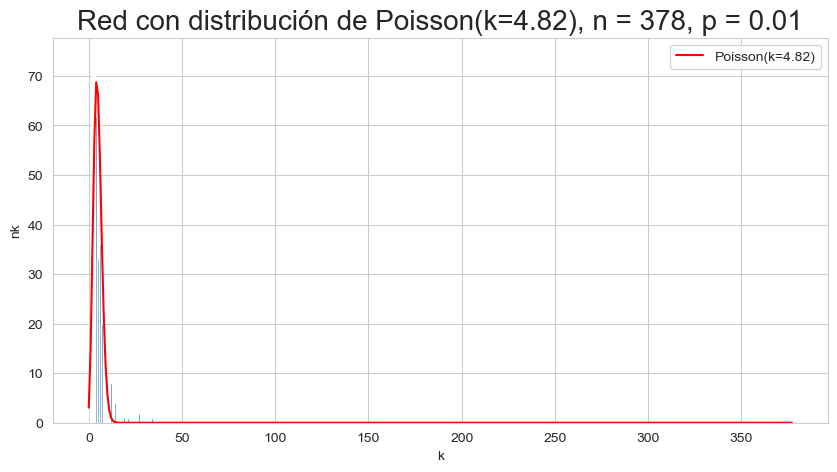

In [43]:
y, x= np.histogram([dict(G.degree)[i] for i in G],bins = range(n))

plt.figure(figsize = [10,5])
plt.plot(x[:-1],poisson.pmf(x[:-1],k)*n, label = f'Poisson(k={k:.2f})', color = 'red')
plt.bar(x[:-1],y)
plt.xlabel('k', size = 10)
plt.ylabel('nk', size = 10)
plt.title(f'Red con distribución de Poisson(k={k:.2f}), n = %i, p = %1.2f' %(n-1,p), size = 20)
plt.legend()

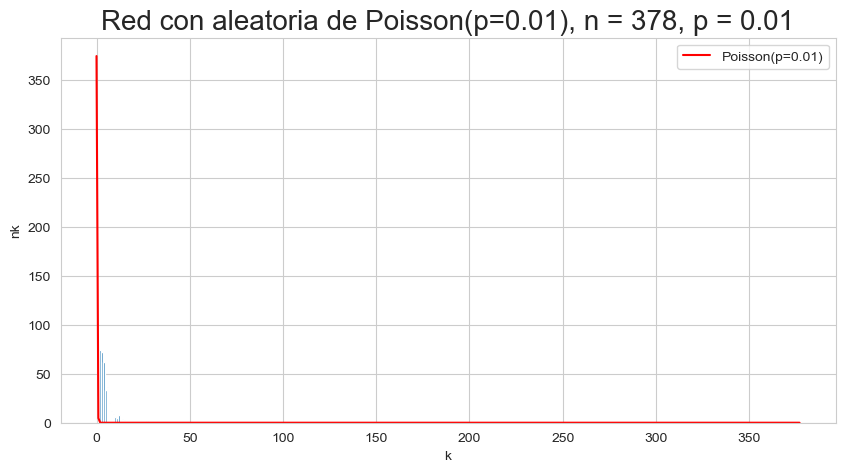

In [44]:
y, x= np.histogram([dict(G.degree)[i] for i in G],bins = range(n))

plt.figure(figsize = [10,5])
plt.plot(x[:-1],poisson.pmf(x[:-1],p)*n, label = f'Poisson(p={p:.2f})', color = 'red')
plt.bar(x[:-1],y)
plt.xlabel('k', size = 10)
plt.ylabel('nk', size = 10)
plt.title(f'Red con aleatoria de Poisson(p={p:.2f}), n = %i, p = %1.2f' %(n-1,p), size = 20)
plt.legend()

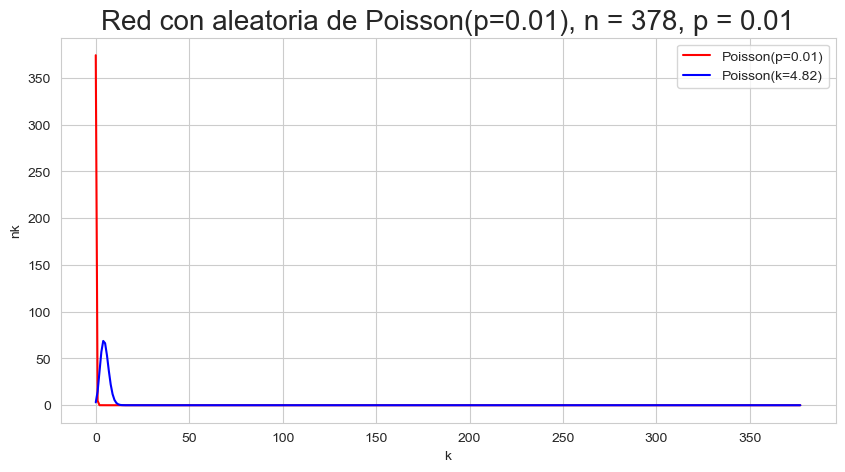

In [45]:
plt.figure(figsize = [10,5])
plt.plot(x[:-1],poisson.pmf(x[:-1],p)*n, label = f'Poisson(p={p:.2f})', color = 'red')
plt.plot(x[:-1],poisson.pmf(x[:-1],k)*n, label = f'Poisson(k={k:.2f})', color = 'blue')
plt.xlabel('k', size = 10)
plt.ylabel('nk', size = 10)
plt.title(f'Red con aleatoria de Poisson(p={p:.2f}), n = %i, p = %1.2f' %(n-1,p), size = 20)
plt.legend()

7. ¿Consideras que la distribución de grado de la red aleatoria correspondiente se ajusta a la distribución de grado de la red real que estás analizando?

In [ ]:
from  scipy.stats import chi2

In [ ]:
# grados observados como enteros
grados = df["Degree"].astype(int).to_numpy()
N = len(grados)
lam = grados.mean()   # también puedes usar k si ya lo calculaste

# categorías: 0, 1, 2, ..., K-1, y cola >= K
K = int(grados.max())

obs = np.array([(grados == i).sum() for i in range(K)])
obs = np.append(obs, (grados >= K).sum())

esp = np.array([N * poisson.pmf(i, lam) for i in range(K)])
esp = np.append(esp, N * (1 - poisson.cdf(K - 1, lam)))

# combinar clases con frecuencia esperada < 5
obs2 = obs.astype(float).copy()
esp2 = esp.astype(float).copy()

i = len(esp2) - 1
while i > 0:
    if esp2[i] < 5:
        esp2[i - 1] += esp2[i]
        obs2[i - 1] += obs2[i]
        esp2 = np.delete(esp2, i)
        obs2 = np.delete(obs2, i)
    i -= 1

chi2_stat = ((obs2 - esp2) ** 2 / esp2).sum()
gl = len(obs2) - 2   # clases finales - 1 - 1 parámetro estimado

p_valor = 1 - chi2.cdf(chi2_stat, df=gl)

print(f"Chi-cuadrada = {chi2_stat:.4f}")
print(f"Grados de libertad = {gl}")
print(f"p-valor = {p_valor:.6f}")

if p_valor < 0.05:
    print(f"\nConclusión: se rechaza H0 con p-valor = {p_valor:.6f}")
    print(f"La distribución de grado de la red real NO se ajusta a una Poisson({lam:.2f}).")
else:
    print(f"\nConclusión: no se rechaza H0 con p-valor = {p_valor:.6f}")
    print(f"La distribución de grado de la red real SÍ es compatible con una Poisson({lam:.2f}).")


Chi-cuadrada = 154.8986
Grados de libertad = 9
p-valor = 0.000000

Conclusión: se rechaza H0 con p-valor = 0.000000
La distribución de grado de la red real NO se ajusta a una Poisson(4.82).


### Coeficiente de agrupamiento de los nodos

Usaremos tres representaciones para comparar los coeficientes de agrupamiento de los nodos de la red real con la red aleatorai equivalente. Ya vimos empíricamente (y veremos en clase) que el coeficiente en una red aleatoria es igual a la probabilidad $p$.

*Si dos nodos son vecinos de un mismo nodo, la probabilidad de que también estén conectados entre sí sigue siendo $p$, ya que las aristas se generan de manera independiente, los triángulos aparecen solo con la frecuencia esperada por azar. Entonces es $C_{WS} = p$*

#### Primera representación

8. Grafica el coeficiente de agrupamiento de los nodos ordenándolos según su etiqueta. Utiliza la columna "Clustering" de la tabla creada anteriormente. En la misma gráfica muestra el valor que predice el modelo de red aleatoria $\left<C'\right> = p$ y el valor de $\left<C\right>$ empírico.

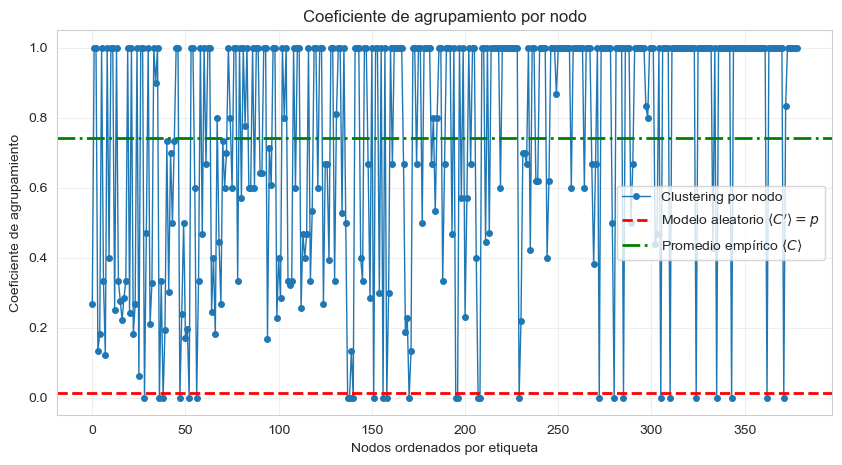

In [64]:
import matplotlib.pyplot as plt
import numpy as np

# ordenar la tabla por la etiqueta del nodo (índice)
df_ordenado = df.sort_index()

# coeficiente de agrupamiento por nodo
clustering_vals = df_ordenado["Clustering"].to_numpy()

# promedio empírico
C_emp = clustering_vals.mean()

# eje x
x = np.arange(len(clustering_vals))

# gráfica
plt.figure(figsize=(10, 5))
plt.plot(x, clustering_vals, 'o-', ms=4, lw=1, label='Clustering por nodo')
plt.axhline(p, color='red', linestyle='--', linewidth=2, label=r"Modelo aleatorio $\langle C' \rangle = p$")
plt.axhline(C_emp, color='green', linestyle='-.', linewidth=2, label=r"Promedio empírico $\langle C \rangle$")

plt.xlabel("Nodos ordenados por etiqueta")
plt.ylabel("Coeficiente de agrupamiento")
plt.title("Coeficiente de agrupamiento por nodo")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


9. ¿El coeficiente de agrupamiento que el modelo predice para cada nodo, se ajusta al coeficiente de agrupamiento de los nodos de tu red?

#### Segunda representación

10. Grafica el coeficiente de agrupamiento de los nodos ordenándolos según su grado. Puedes utilizar y ordenar la columna "Degree" de la tabla creada anteriormente. En la misma gráfica muestra el valor que predice el modelo de red aleatoria  ⟨𝐶′⟩=𝑝 y el valor de  ⟨𝐶⟩  empírico.

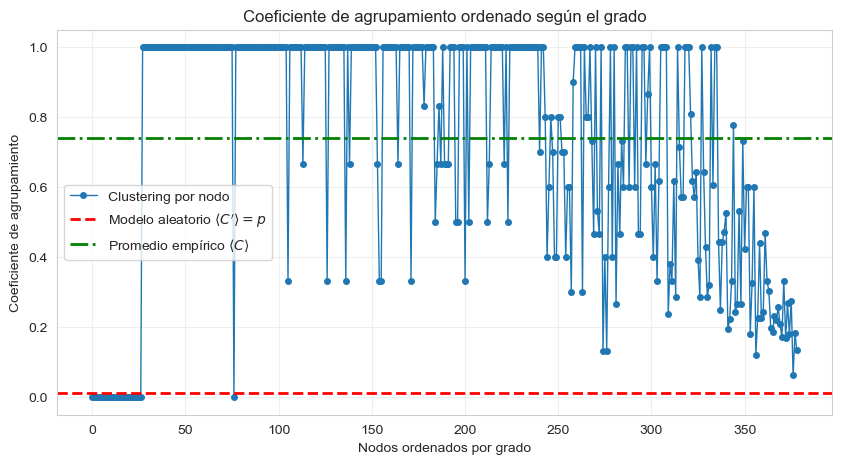

In [65]:
import matplotlib.pyplot as plt
import numpy as np

# ordenar por grado
df_ordenado_grado = df.sort_values("Degree")

# coeficiente de agrupamiento de los nodos ordenados por grado
clustering_vals = df_ordenado_grado["Clustering"].to_numpy()

# promedio empírico
C_emp = clustering_vals.mean()

# eje x
x = np.arange(len(clustering_vals))

# gráfica
plt.figure(figsize=(10, 5))
plt.plot(x, clustering_vals, 'o-', ms=4, lw=1, label='Clustering por nodo')
plt.axhline(p, color='red', linestyle='--', linewidth=2, label=r"Modelo aleatorio $\langle C' \rangle = p$")
plt.axhline(C_emp, color='green', linestyle='-.', linewidth=2, label=r"Promedio empírico $\langle C \rangle$")

plt.xlabel("Nodos ordenados por grado")
plt.ylabel("Coeficiente de agrupamiento")
plt.title("Coeficiente de agrupamiento ordenado según el grado")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


11. ¿Consideras que hay alguna correlación o patrón interesante entre el grado y el coeficiente de agrupamiento de los nodos?

Coeficiente de Spearman (rho) = -0.2982
p-valor = 0.000000

Conclusión: hay evidencia estadísticamente significativa de correlación entre el grado y el coeficiente de agrupamiento.


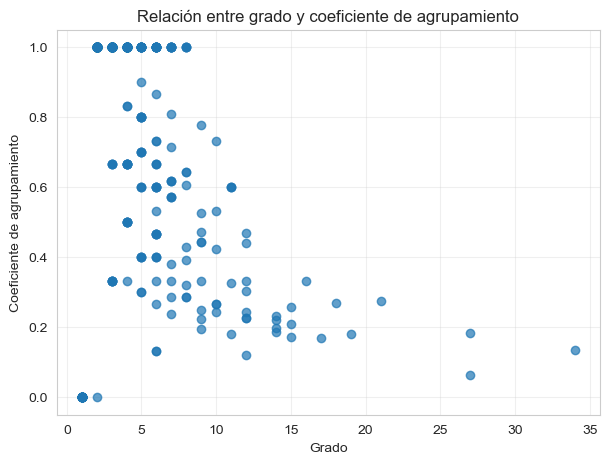

In [66]:
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# tomar los datos
x = df["Degree"].astype(float)
y = df["Clustering"].astype(float)

# prueba de correlación de Spearman
rho, p_valor = spearmanr(x, y)

print(f"Coeficiente de Spearman (rho) = {rho:.4f}")
print(f"p-valor = {p_valor:.6f}")

alpha = 0.05
if p_valor < alpha:
    print("\nConclusión: hay evidencia estadísticamente significativa de correlación entre el grado y el coeficiente de agrupamiento.")
else:
    print("\nConclusión: no hay evidencia estadísticamente significativa de correlación entre el grado y el coeficiente de agrupamiento.")

# gráfica de apoyo
plt.figure(figsize=(7,5))
plt.scatter(x, y, alpha=0.7)
plt.xlabel("Grado")
plt.ylabel("Coeficiente de agrupamiento")
plt.title("Relación entre grado y coeficiente de agrupamiento")
plt.grid(alpha=0.3)
plt.show()


#### Tercera representación.

11. Realiza una gráfica del coeficiente de agrupamiento promedio de los nodos, agrupados según se grado:

- Agrupa los elementos de la tabla según su valor de grado (puedes usar la función .groupby de pandas)
- De la tabla agrupada, considera solamente la columna "Clustering"
- De la propiead "Clustering" de los datos ya agrupados, calcula el promedio (puedes usar la función .mean())
- Forman los arreglos correspondientes al grado y al promedio del coeficiente de agrupamiento, puedes aplicar tres funciones seguidas: .reset_index().values.T
- Realiza la gráfica del coeficiente de agrupamiento promedio del grupo de nodos con grado $k$, denotado por $C(k)$. Indica los valores del promedio empírico y del predicho por el modelo de red aleatoria para obtener conclusiones.

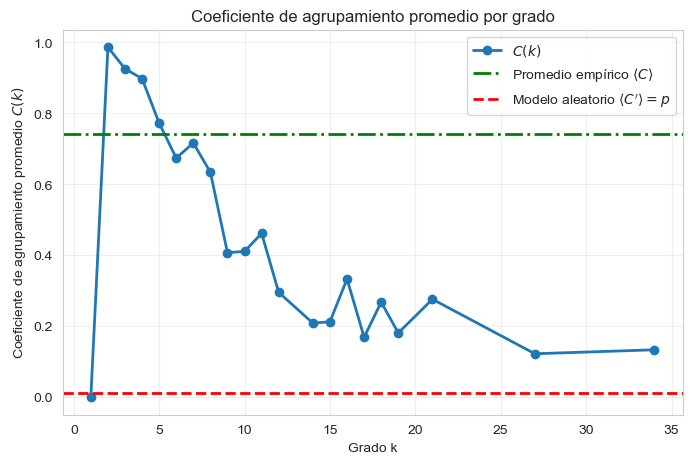

In [67]:
import matplotlib.pyplot as plt

# agrupar por grado y calcular el promedio de clustering
ck_df = df.groupby("Degree")["Clustering"].mean()

# formar los arreglos grado y C(k)
grado, Ck = ck_df.reset_index().values.T

# promedio empírico global
C_emp = df["Clustering"].mean()

# gráfica
plt.figure(figsize=(8,5))
plt.plot(grado, Ck, 'o-', linewidth=2, label=r"$C(k)$")
plt.axhline(C_emp, color='green', linestyle='-.', linewidth=2, label=r"Promedio empírico $\langle C \rangle$")
plt.axhline(p, color='red', linestyle='--', linewidth=2, label=r"Modelo aleatorio $\langle C' \rangle = p$")

plt.xlabel("Grado k")
plt.ylabel(r"Coeficiente de agrupamiento promedio $C(k)$")
plt.title(r"Coeficiente de agrupamiento promedio por grado")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


12. En esta representación, ¿encuentras alguna correlación o patrón interesante entre los valores de  $k$ y  $C(k)$ ?

Coeficiente de Spearman (rho) = -0.6753
p-valor = 0.000782

Conclusión: hay una correlación negativa significativa entre k y C(k).


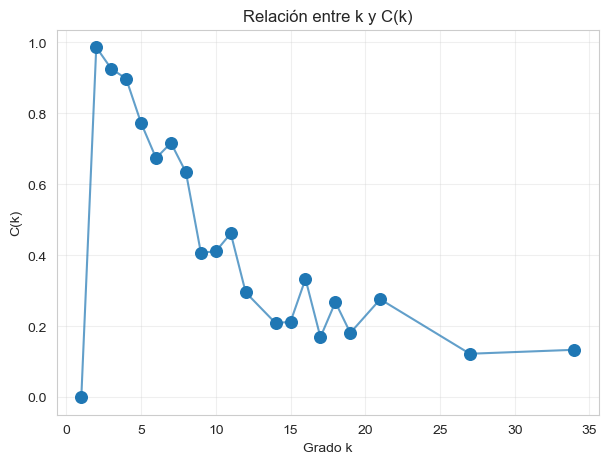

In [68]:
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

# prueba de correlación entre k y C(k)
rho, p_valor = spearmanr(grado, Ck)

print(f"Coeficiente de Spearman (rho) = {rho:.4f}")
print(f"p-valor = {p_valor:.6f}")

if p_valor < 0.05:
    if rho > 0:
        print("\nConclusión: hay una correlación positiva significativa entre k y C(k).")
    else:
        print("\nConclusión: hay una correlación negativa significativa entre k y C(k).")
else:
    print("\nConclusión: no hay evidencia estadísticamente significativa de correlación entre k y C(k).")

# gráfica de apoyo
plt.figure(figsize=(7,5))
plt.scatter(grado, Ck, s=70)
plt.plot(grado, Ck, alpha=0.7)
plt.xlabel("Grado k")
plt.ylabel("C(k)")
plt.title("Relación entre k y C(k)")
plt.grid(alpha=0.3)
plt.show()
